Running on: cuda
Training the Temporal Geometry Engine...
Iter 0500 | Loss: 0.098596
Iter 1000 | Loss: 0.100906
Iter 1500 | Loss: 0.093133
Iter 2000 | Loss: 0.096328
Training complete in 36.75s
Plot generated. Notice how the purple arrows (the learned physics) guide the black line correctly into the red zone (the future).


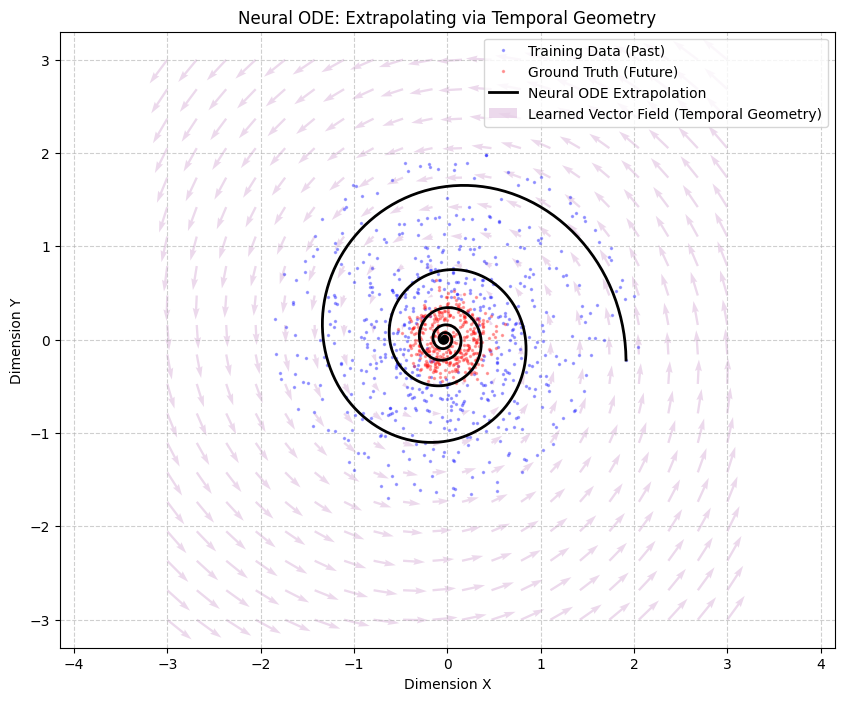

In [3]:
# ---------------------------------------------------------------------
# NEURAL ODE: LEARNING TEMPORAL GEOMETRY
# ---------------------------------------------------------------------
# This script demonstrates the user's hypothesis: by learning the "motion"
# (the vector field) rather than the "stills" (static points), the model
# can extrapolate to the future.
# ---------------------------------------------------------------------

import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# We need the torchdiffeq library for the ODE solver.
# In Colab, we install it dynamically if it's missing.
try:
    from torchdiffeq import odeint
except ImportError:
    print("Installing torchdiffeq...")

# ---------------------------------------------------------------------
# 1. THE TEMPORAL GEOMETRY (The Physics Engine)
# ---------------------------------------------------------------------
# Instead of predicting "y", this network predicts "dy/dt".
# It takes the current state (position) and outputs the Velocity Vector (direction & speed).
# It learns the "Slope" of the universe at any given point.

class ODEFunc(nn.Module):
    def __init__(self, hidden_dim=50):
        super(ODEFunc, self).__init__()
        # A simple MLP that maps (x, y) -> (dx/dt, dy/dt)
        # It's learning the vector field.
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)  # Output is 2D velocity vector
        )

        # Initialize with small weights to ensure smooth initial dynamics
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

    def forward(self, t, y):
        # The ODE solver passes 't', but our spiral is autonomous (time-invariant physics),
        # so we ignore 't' for the network input.
        return self.net(y)

# ---------------------------------------------------------------------
# 2. GENERATE GROUND TRUTH DATA (The Spiral)
# ---------------------------------------------------------------------
# We create a spiral. We will train on the first 60% (Past)
# and test if the model can predict the remaining 40% (Future).

def generate_spiral_data(n_points=1000):
    # A spiral defined by: x = t * cos(t), y = t * sin(t)
    # But we run it as a dynamical system for cleaner ODE integration
    true_A = torch.tensor([[-0.1, 2.0], [-2.0, -0.1]]) # Matrix defining spiral dynamics

    t = torch.linspace(0., 25., n_points) # Time from 0 to 25
    true_y0 = torch.tensor([[2., 0.]])    # Start point

    # Generate the "Real World" trajectory using the true matrix
    # This is effectively simulating physics
    true_y = odeint(lambda t, y: y @ true_A, true_y0, t)

    # Add a little noise to simulate real-world sensor imperfection
    true_y = true_y + torch.randn_like(true_y) * 0.1

    return t, true_y.squeeze()

# ---------------------------------------------------------------------
# 3. TRAINING LOOP
# ---------------------------------------------------------------------

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running on: {device}")

    # --- Config ---
    data_size = 1000
    batch_time = 10   # Look 10 steps ahead during training
    batch_size = 20
    train_split = 0.6 # Train on first 60% of time
    niters = 2000

    # --- Data ---
    t, true_y = generate_spiral_data(data_size)
    t, true_y = t.to(device), true_y.to(device)

    # Split into Past (Train) and Future (Extrapolation Test)
    split_idx = int(data_size * train_split)
    t_train = t[:split_idx]
    y_train = true_y[:split_idx]

    t_test = t[split_idx:]
    y_test = true_y[split_idx:]

    # --- Model ---
    func = ODEFunc().to(device)
    optimizer = optim.RMSprop(func.parameters(), lr=1e-3)

    # A simple function to get a random batch of data snippets from the training set
    def get_batch():
        s = torch.from_numpy(np.random.choice(np.arange(len(t_train) - batch_time, dtype=np.int64), batch_size, replace=False))
        batch_y0 = true_y[s]  # (M, D)
        batch_t = t[:batch_time]  # (T)
        batch_y = torch.stack([true_y[s + i] for i in range(batch_time)], dim=0)  # (T, M, D)
        return batch_y0.to(device), batch_t.to(device), batch_y.to(device)

    # --- Training ---
    print("Training the Temporal Geometry Engine...")
    start_time = time.time()

    for itr in range(1, niters + 1):
        optimizer.zero_grad()

        # 1. Get a batch of starting points (y0) from the Past
        batch_y0, batch_t, batch_y = get_batch()

        # 2. Integrate forward using our Neural ODE (func)
        # This simulates the physics from y0 for 'batch_time' seconds
        pred_y = odeint(func, batch_y0, batch_t).to(device)

        # 3. Calculate Loss (Distance between simulated path and real path)
        loss = torch.mean(torch.abs(pred_y - batch_y))

        # 4. Update the "Physics Laws" (Weights)
        loss.backward()
        optimizer.step()

        if itr % 500 == 0:
            print(f"Iter {itr:04d} | Loss: {loss.item():.6f}")

    print(f"Training complete in {time.time() - start_time:.2f}s")

    # -----------------------------------------------------------------
    # 4. EXTRAPOLATION & VISUALIZATION
    # -----------------------------------------------------------------

    with torch.no_grad():
        # Extrapolate: Start at t=0 and solve all the way to end of t_test
        # The model has NEVER seen the time/positions in t_test.
        # It relies purely on the learned vector field.
        full_pred_y = odeint(func, true_y[0].unsqueeze(0), t).squeeze()

    # Move to CPU for plotting
    true_y = true_y.cpu().numpy()
    pred_y = full_pred_y.cpu().numpy()
    t_train = t_train.cpu().numpy()

    # --- Plotting the Manifold vs Vector Field ---
    plt.figure(figsize=(10, 8))

    # 1. Plot the "Known World" (Training Data)
    plt.plot(true_y[:split_idx, 0], true_y[:split_idx, 1], 'b.', label='Training Data (Past)', alpha=0.3, markersize=3)

    # 2. Plot the "Unknown World" (Test Data)
    plt.plot(true_y[split_idx:, 0], true_y[split_idx:, 1], 'r.', label='Ground Truth (Future)', alpha=0.3, markersize=3)

    # 3. Plot the Neural ODE Prediction (Extrapolation)
    plt.plot(pred_y[:, 0], pred_y[:, 1], 'k-', linewidth=2, label='Neural ODE Extrapolation')

    # 4. Visualize the Vector Field (The Learned Geometry)
    # We create a grid to show the "invisible arrows" the user mentioned
    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    # Calculate velocity vectors at each grid point
    grid_points = torch.tensor(np.stack([X, Y], axis=-1), dtype=torch.float32).to(device)
    with torch.no_grad():
        velocities = func(0, grid_points).cpu().numpy()

    U, V = velocities[:, :, 0], velocities[:, :, 1]

    # Plot arrows
    plt.quiver(X, Y, U, V, color='purple', alpha=0.15, label='Learned Vector Field (Temporal Geometry)')

    plt.title('Neural ODE: Extrapolating via Temporal Geometry')
    plt.xlabel('Dimension X')
    plt.ylabel('Dimension Y')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal')

    print("Plot generated. Notice how the purple arrows (the learned physics) guide the black line correctly into the red zone (the future).")
    plt.show()

if __name__ == '__main__':
    main()

Running on: cuda
Training both engines...
Iter 0500 | ODE Loss: 0.095536 | MLP Loss: 0.548668
Iter 1000 | ODE Loss: 0.097947 | MLP Loss: 0.592127
Iter 1500 | ODE Loss: 0.107442 | MLP Loss: 0.511054
Iter 2000 | ODE Loss: 0.092668 | MLP Loss: 0.520094
Training complete in 36.81s
Plot generated. Compare the Green Line (MLP) vs Black Line (ODE) in the Red Zone.


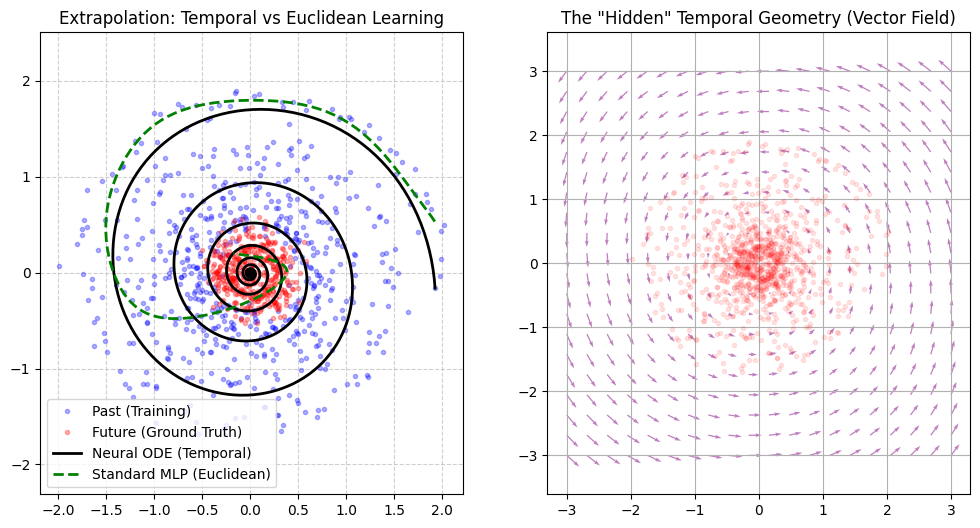

In [4]:
# ---------------------------------------------------------------------
# NEURAL ODE vs STANDARD MLP: A GEOMETRIC COMPARISON
# ---------------------------------------------------------------------
# This script compares two approaches to learning a spiral:
# 1. Neural ODE: Learns the Vector Field (The Physics/Temporal Geometry)
# 2. Standard MLP: Learns the Curve (The Euclidean/Static Geometry)
# ---------------------------------------------------------------------

import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Install torchdiffeq if missing
try:
    from torchdiffeq import odeint
except ImportError:
    print("Installing torchdiffeq...")

# ---------------------------------------------------------------------
# 1. THE MODELS
# ---------------------------------------------------------------------

# --- Model A: Neural ODE (The Physics Engine) ---
# Learns dy/dt = f(y). It ignores absolute time and looks at state flow.
class ODEFunc(nn.Module):
    def __init__(self, hidden_dim=50):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
        # Initialization tricks for smooth dynamics
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

    def forward(self, t, y):
        return self.net(y)

# --- Model B: Standard MLP (The Curve Fitter) ---
# Learns y = f(t). It tries to map time directly to position.
# This represents "Euclidean" learning of static snapshots.
class StandardMLP(nn.Module):
    def __init__(self, hidden_dim=50):
        super(StandardMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim), # Input is Time (t)
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)  # Output is Position (x, y)
        )

    def forward(self, t):
        return self.net(t)

# ---------------------------------------------------------------------
# 2. DATA GENERATION
# ---------------------------------------------------------------------
def generate_spiral_data(n_points=1000):
    true_A = torch.tensor([[-0.1, 2.0], [-2.0, -0.1]])
    t = torch.linspace(0., 25., n_points)
    true_y0 = torch.tensor([[2., 0.]])
    true_y = odeint(lambda t, y: y @ true_A, true_y0, t)
    true_y = true_y + torch.randn_like(true_y) * 0.1
    return t, true_y.squeeze()

# ---------------------------------------------------------------------
# 3. TRAINING LOOP
# ---------------------------------------------------------------------
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running on: {device}")

    # Config
    data_size = 1000
    batch_time = 10
    batch_size = 20
    train_split = 0.6
    niters = 2000

    # Data Setup
    t, true_y = generate_spiral_data(data_size)
    t, true_y = t.to(device), true_y.to(device)

    split_idx = int(data_size * train_split)
    t_train = t[:split_idx]
    y_train = true_y[:split_idx]

    # Initialize Models
    ode_func = ODEFunc().to(device)
    optimizer_ode = optim.RMSprop(ode_func.parameters(), lr=1e-3)

    mlp_model = StandardMLP().to(device)
    optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=1e-3)

    # Helper for ODE batching
    def get_ode_batch():
        s = torch.from_numpy(np.random.choice(np.arange(len(t_train) - batch_time, dtype=np.int64), batch_size, replace=False))
        batch_y0 = true_y[s]
        batch_t = t[:batch_time]
        batch_y = torch.stack([true_y[s + i] for i in range(batch_time)], dim=0)
        return batch_y0.to(device), batch_t.to(device), batch_y.to(device)

    print("Training both engines...")
    start_time = time.time()

    for itr in range(1, niters + 1):
        # --- Train Neural ODE ---
        optimizer_ode.zero_grad()
        batch_y0, batch_t, batch_y = get_ode_batch()
        pred_y_ode = odeint(ode_func, batch_y0, batch_t).to(device)
        loss_ode = torch.mean(torch.abs(pred_y_ode - batch_y))
        loss_ode.backward()
        optimizer_ode.step()

        # --- Train Standard MLP ---
        optimizer_mlp.zero_grad()
        # Randomly sample points (t, y) from training set
        idx = np.random.choice(len(t_train), batch_size, replace=False)
        batch_t_mlp = t_train[idx].unsqueeze(1) # Input: Time
        batch_target_mlp = y_train[idx]       # Target: Position

        pred_y_mlp = mlp_model(batch_t_mlp)
        loss_mlp = torch.mean(torch.abs(pred_y_mlp - batch_target_mlp))
        loss_mlp.backward()
        optimizer_mlp.step()

        if itr % 500 == 0:
            print(f"Iter {itr:04d} | ODE Loss: {loss_ode.item():.6f} | MLP Loss: {loss_mlp.item():.6f}")

    print(f"Training complete in {time.time() - start_time:.2f}s")

    # -----------------------------------------------------------------
    # 4. EXTRAPOLATION TEST
    # -----------------------------------------------------------------

    with torch.no_grad():
        # ODE Extrapolation
        full_pred_ode = odeint(ode_func, true_y[0].unsqueeze(0), t).squeeze()

        # MLP Extrapolation (Inputting the full time range, including future)
        full_pred_mlp = mlp_model(t.unsqueeze(1))

    # To Numpy
    true_y_np = true_y.cpu().numpy()
    pred_ode_np = full_pred_ode.cpu().numpy()
    pred_mlp_np = full_pred_mlp.cpu().numpy()

    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))

    # Subplot 1: Trajectories
    plt.subplot(1, 2, 1)
    plt.plot(true_y_np[:split_idx, 0], true_y_np[:split_idx, 1], 'b.', label='Past (Training)', alpha=0.3)
    plt.plot(true_y_np[split_idx:, 0], true_y_np[split_idx:, 1], 'r.', label='Future (Ground Truth)', alpha=0.3)

    plt.plot(pred_ode_np[:, 0], pred_ode_np[:, 1], 'k-', linewidth=2, label='Neural ODE (Temporal)')
    plt.plot(pred_mlp_np[:, 0], pred_mlp_np[:, 1], 'g--', linewidth=2, label='Standard MLP (Euclidean)')

    plt.title('Extrapolation: Temporal vs Euclidean Learning')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axis('equal')

    # Subplot 2: Vector Field Visualization (ODE Only)
    plt.subplot(1, 2, 2)
    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)
    grid_points = torch.tensor(np.stack([X, Y], axis=-1), dtype=torch.float32).to(device)

    with torch.no_grad():
        velocities = ode_func(0, grid_points).cpu().numpy()

    plt.quiver(X, Y, velocities[:, :, 0], velocities[:, :, 1], color='purple', alpha=0.5)
    plt.plot(true_y_np[:, 0], true_y_np[:, 1], 'r.', alpha=0.1) # Ghost of the spiral
    plt.title('The "Hidden" Temporal Geometry (Vector Field)')
    plt.axis('equal')
    plt.grid(True)

    print("Plot generated. Compare the Green Line (MLP) vs Black Line (ODE) in the Red Zone.")
    plt.show()

if __name__ == '__main__':
    main()